In [1]:
import tables
import numpy as np
import matplotlib.pyplot as plt
from icecube.phys_services import I3Calculator
import random

params = {'figure.figsize': (7, 7*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

np.random.seed(47)

/nue_cc/Beta1Reco (EArray(558340,)) ''


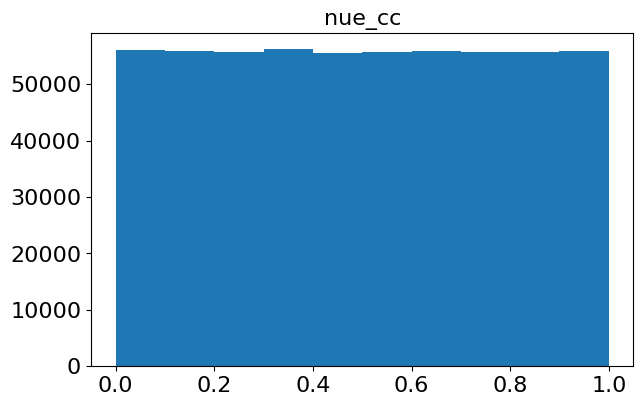

/nue_nc/Beta1Reco (EArray(77559,)) ''


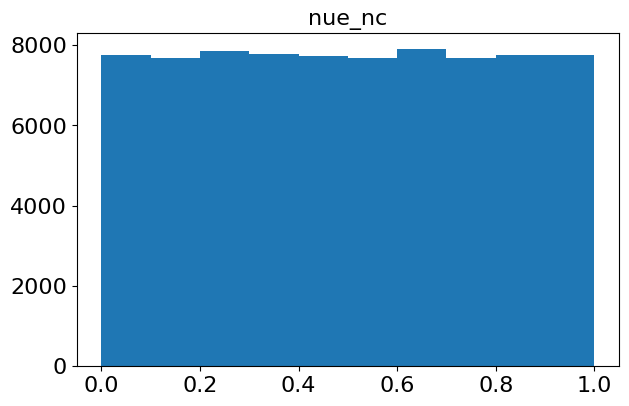

/nuebar_cc/Beta1Reco (EArray(229767,)) ''


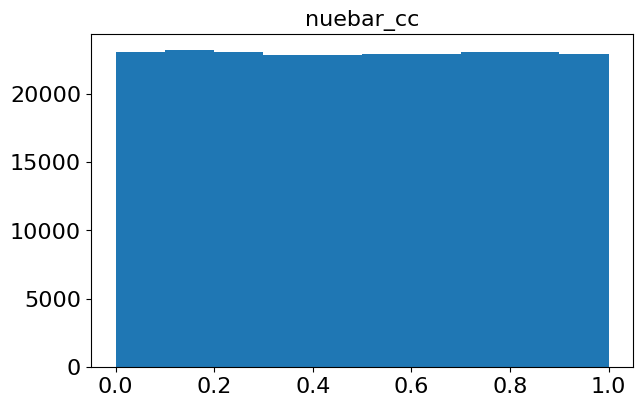

/nuebar_nc/Beta1Reco (EArray(25724,)) ''


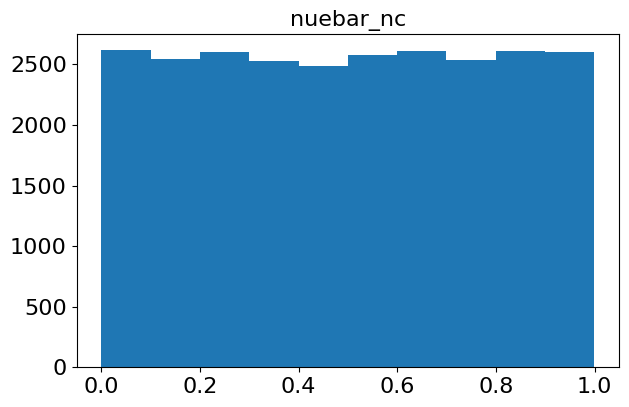

/numu_cc/Beta1Reco (EArray(1042943,)) ''


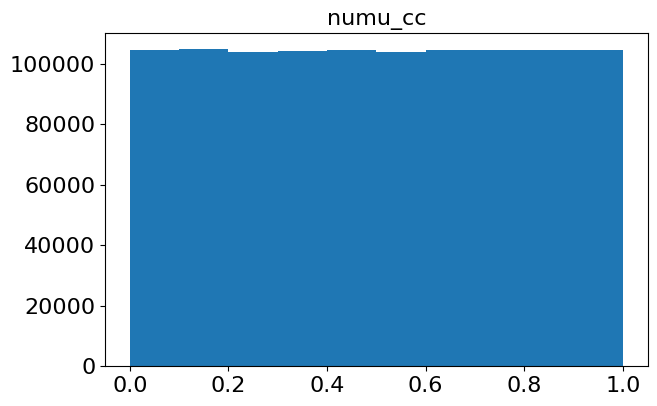

/numu_nc/Beta1Reco (EArray(148170,)) ''


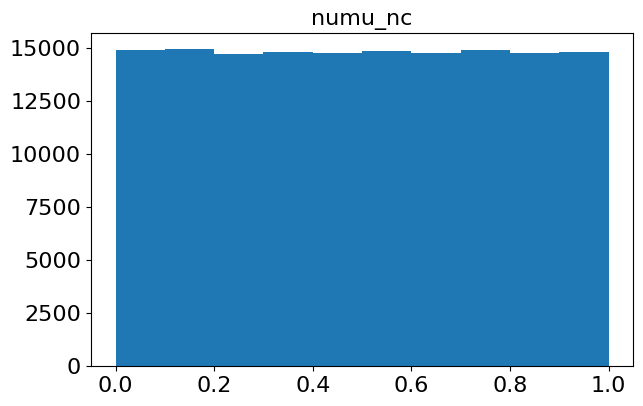

/numubar_cc/Beta1Reco (EArray(487936,)) ''


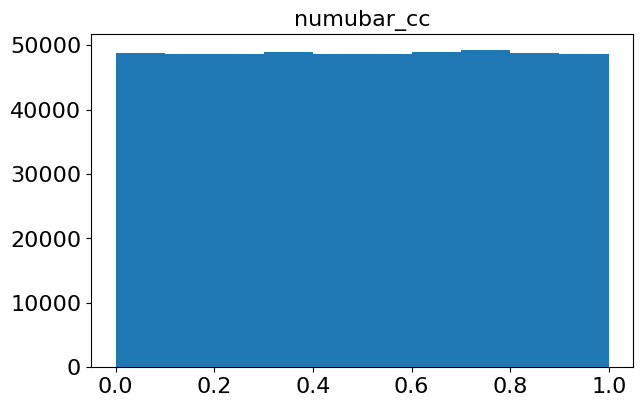

/numubar_nc/Beta1Reco (EArray(53954,)) ''


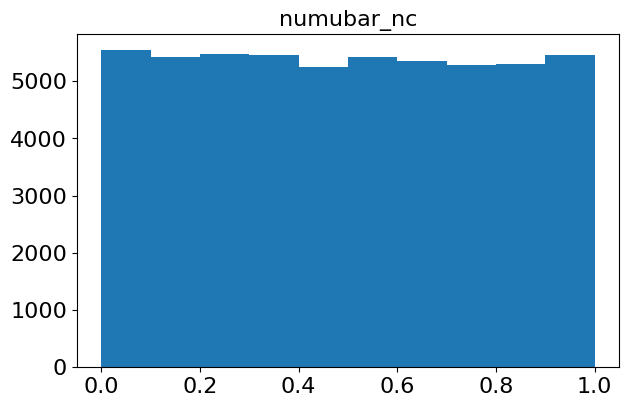

/nutau_cc/Beta1Reco (EArray(107446,)) ''


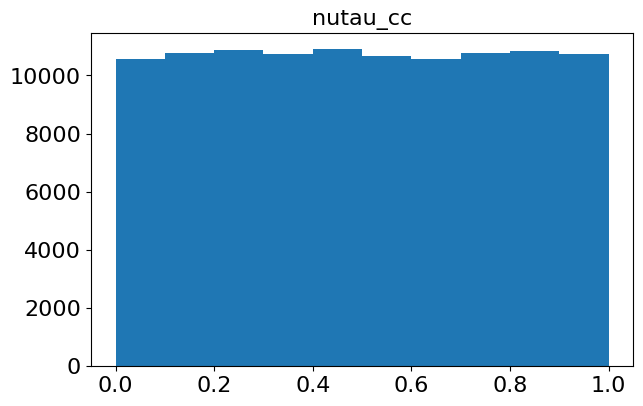

/nutau_nc/Beta1Reco (EArray(108167,)) ''


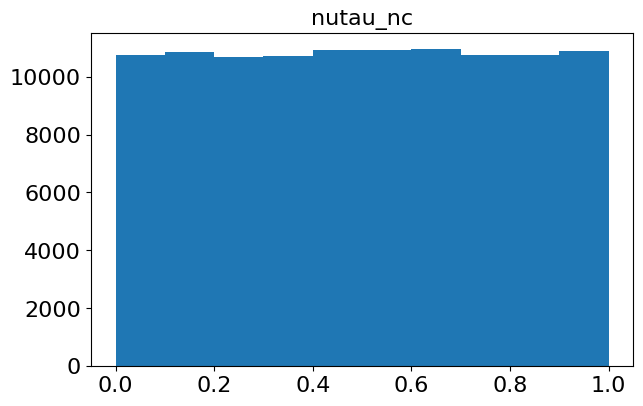

/nutaubar_cc/Beta1Reco (EArray(53731,)) ''


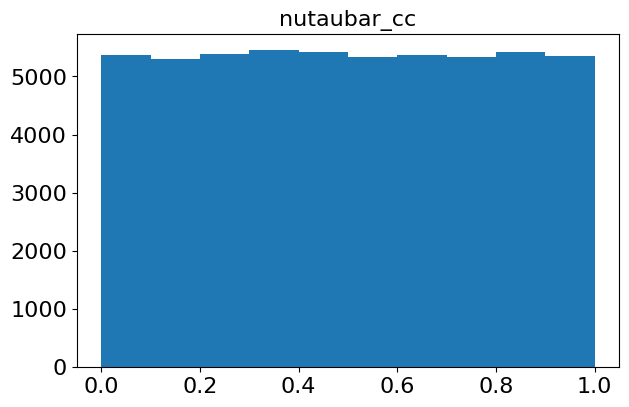

/nutaubar_nc/Beta1Reco (EArray(38846,)) ''


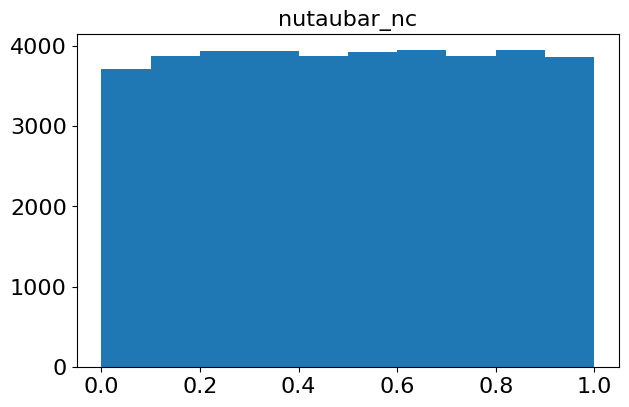

In [4]:
group_names = [
    'nue_cc', 'nue_nc', 'nuebar_cc', 'nuebar_nc',
    'numu_cc', 'numu_nc', 'numubar_cc', 'numubar_nc',
    'nutau_cc', 'nutau_nc', 'nutaubar_cc', 'nutaubar_nc'
]


with tables.open_file("/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_extended.hdf5", mode="a") as file:
    for group_name in group_names:
        group = getattr(file.root, group_name)

        table = None

        for node in group:
            if isinstance(node, tables.Array):
                print(node)
                table = node
                break

        if table is None:
            print(f" No table found in group {group_name}")

        rand_arr = np.random.uniform(0, 1, table.nrows)

        plt.hist(rand_arr)
        plt.title(group_name)
        plt.show()

        if hasattr(group, 'RandomNumber'):
            print(f"RandomWeight already exists in {group_name}")
        else:
            file.create_array(group, 'RandomNumber', obj=rand_array)
            print(f"Added RandomNumber to {group_name}")
        
        

In [3]:
group

<closed tables.group.Group at 0x7fc53fdbfed0>